# Модель предсказания возрастной группы посетителей сайтов

## Содержание
1. <a href="#intro">Введение</a>
1. <a href="#preparation">Подготовка данных</a>
1. <a href="#eda">Исследовательский анализ данных</a>
1. <a href="#preprocessing">Предобработка датасета</a>
1. <a href="#baseline">Обучение и оценка базовой модели</a>
1. <a href="#feature-engineering">Создание и отбор признаков</a>
1. <a href="#hyperparameters">Подбор гиперпараметров</a>
1. <a href="#save-model">Подготовка артефактов модели для внедрения</a>
1. <a href="#final-report">Выводы исследования</a>

<a id="intro"></a>



## Введение

### Бизнес-контекст

Компания Йети, владелет рекламной сети РСЙ, для улучшения маркетинговых рекламных кампаний решила использовать дополнительные сведения о возрасте посетителей сайтов. Компания владеет большим объемом информации о сессиях пользователей на различных рекламных площадках, например, о категориях сайтов, о глубине просмотра и так далее.

Требуется построить модель машинного обучения, которая бы предсказывала по перечисленным признакам возрастную группу пользователя. Данный признак в совокупности с другой информацией о пользователе позволит более эффективно участвовать в рекламных аукционах и подбирать для пользователей подходящие рекламные объявления.

Кроме того, в некоторых странах, за показ несоответствующей рекламы для определенных групп пользователей предусмотрены юридические последствия, поэтому важно определять возраст достаточно точно.

### Цель исследования

Построить модель машинного обучения, которая по различным признакам пользователя будет предсказывать его возрастную группу в форме одной из категорий с диапазонами лет.

### Постановка задачи машинного обучения

В предоставленных данных имеется целевая переменная - возрастная группа пользователя. Мы имеем дело с задачей обучение с учителем. Возрастные группы подразделяются на:
- 0: младше 18;
- 1: 18-25 лет;
- 2: 26-40 лет;
- 3: 41-55 лет;
- 4: 56+ лет.

Целевая переменная представляет несколько допустимых значений (возрастных диапазонов), таким образом необходимо решить задачу многоклассовой классификации.

В качестве модели будем использовать несколько вариантов:
- Логистическая регрессия, как базовый алгоритм
- Метод опорных векторов с различными ядрами для улавливания нелинейных зависимостей признаков с целевой переменной.

**Метрики качества**

В роли основной метрики качества используем F1-меру с макро ксредненим для того, чтобы оценить модель даже на узко представленных возрастных группах. Вспомогательные метрики $Precision(k)_{macro}$, $Recall(k)_{macro}$ для полного понимани сильных и слабых сторон модели в целях бизнес-анализа.

Значение F1-меры лучшей модели должно быть не меньше 0.75 на тесте для успешного внедрения модели в производственную эксплуатацию.

Калибровка вероятностей предсказания классов не требуется, так как вероятности не используются, а требуется только определение класса возрастной группы пользователя.

<a id="preparation"></a>

## Подготовка среды и библиотек

Установим зависимости:

In [1]:
from pathlib import Path

requirements_file = Path('requirements.txt')
requirements = [
    'phik==0.12.5',
    'joblib==1.5.3',
    'scikit-learn==1.6.1',
    'seaborn==0.13.2',
]
if not requirements_file.exists():
    with open(requirements_file, 'w') as f:
        f.write('\n'.join(requirements))
        print(f'{requirements_file} created')
else:
    print(f'{requirements_file} exists')

print('Installing requirements...')
!pip install -r requirements.txt
print('Requirements have been installed!')


requirements.txt exists
Installing requirements...
Requirements have been installed!


Импортируем необходимые классы и функции:

In [2]:
import os
import requests
from datetime import datetime
from time import time
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import FunctionTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import RFE
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.calibration import calibration_curve, CalibrationDisplay
from sklearn.calibration import CalibratedClassifierCV
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier


from scipy.stats import uniform, loguniform
from phik import phik_matrix


Зафиксируем RANDOM_STATE для воспроизводимости результатов и настроим отображение ячеек в ноутбуке:

In [3]:
RANDOM_STATE = 153
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', None) # выводить все колонки
pd.set_option('display.max_colwidth', 500) # выводить больше символов в ячейке


Определим утилитарные функции:

In [4]:
#### Загрузка датасета
def load_dataset(
    dataset_url,
    local_file,
    local_path='datasets',
    sep=',',
    decimal='.'
):
    local_dataset_file = f'{local_path}/{local_file}'
    remote_dataset_url = dataset_url
    def read_dataset_csv():
        return pd.read_csv(local_dataset_file, sep=sep, decimal=decimal)

    try:
        df = read_dataset_csv()
        print(f'Датасет успешно загружен из {local_dataset_file}')
    except FileNotFoundError:
        os.makedirs(local_path, exist_ok=True)
        print(f'Файл не найден. Загружаем файл в {local_dataset_file} из {remote_dataset_url}')
        response = requests.get(remote_dataset_url)
        if response.status_code == 200:
            with open(local_dataset_file, 'wb') as f:
                f.write(response.content)
            print(f'Файл с датасетом успешно загружен в {local_dataset_file}')
            df = read_dataset_csv()
        else:
            raise NetworkError(f'Ошибка при загрузке файла: {response.status_code}')

    print(f'Размер загруженного датасета: {df.shape[0]} строк, {df.shape[1]} столбцов', )
    return df

def df_info(df, name, n_samples=3):
    print('-'*50)
    print(f'Описание датасета {name}:')
    print('-'*50)
    print(df.info())
    print('-'*50)
    print(f'Данные датасета {name}:')
    print('-'*50)
    display(
        pd.concat([
            df.head(n_samples).assign(place='head'),
            df.sample(n_samples, random_state=RANDOM_STATE).assign(place='random'),
            df.tail(n_samples).assign(place='tail'),
        ]).sort_index()
    )

#### EDA
class CorrelationDisplayer:
    """
    Класс для отображения матрицы корреляций признаков в разных видах
    """
    def __init__(self, corr_matrix):
        self.corr_matrix = corr_matrix

    def get_corr_matrix(self):
        return self.corr_matrix

    def _subset_corr_matrix(self, subset):
        subset_cols = self.corr_matrix.columns if subset is None else subset
        return self.corr_matrix.loc[subset_cols, subset_cols]

    def draw_corr_matrix_full(
            self,
            digits=2,
            title='Матрица корреляций признаков',
            subtitle=None,
            figsize=(16, 10),
            subset=None,
    ):
        plt.subplots(figsize=figsize)
        matrix = self._subset_corr_matrix(subset)
        sns.heatmap(matrix.round(digits), annot=True, cmap='coolwarm', linewidths=0.5)
        plt.title(title + "\n" + subtitle if subtitle else title)
        plt.show()


    def draw_corr_matrix_with_target(
            self,
            target_col,
            title='Матрица корреляций с таргетом',
            subtitle=None,
            figsize=(16, 10),
    ):
        plt.subplots(figsize=figsize)
        data_heatmap = self.corr_matrix.loc[
            self.corr_matrix.index != target_col
        ][[target_col]].sort_values(by=target_col, ascending=False)
        sns.heatmap(data_heatmap, annot=True, cmap='coolwarm', linewidths=0.5)
        plt.title(title + "\n" + subtitle if subtitle else title)
        plt.show()

    def draw_pair_correlations(self, subset=None, figsize=(16, 10), corr_threshold=0.9):
        # преобразуем матрицу корреляции в датафрейм попарных корреляций
        # feature_1+feature_2 -> correlation
        matrix = self._subset_corr_matrix(subset)
        pair_correlations = matrix \
            .stack() \
            .reset_index() \
            .rename(columns={
                'level_0': 'feature1',
                'level_1': 'feature2',
                0: 'correlation'
            }) \
            .query('feature1 != feature2') \
            .sort_values(by='correlation', ascending=False) \

        def order_pair(row):
            if row['feature1'] > row['feature2']:
                return row['feature2'] + '/' + row['feature1']
            else:
                return row['feature1'] + '/' + row['feature2']

        pair_correlations['order_pair'] = pair_correlations.apply(order_pair, axis=1)
        pair_correlations = pair_correlations.drop(columns=['feature1', 'feature2'])
        pair_correlations = pair_correlations.drop_duplicates().reset_index(drop=True)
        pair_correlations = pair_correlations.query('correlation > @corr_threshold')
        pair_correlations = pair_correlations.sort_values(by='correlation')
        pair_correlations.plot(
            x='order_pair',
            y='correlation',
            xlabel='Значение корреляции',
            ylabel='Пара признаков',
            kind='barh',
            legend=False,
            figsize=figsize,
            grid=True,
        )
        plt.title('Попарные корреляции')
        plt.show()
        return pair_correlations.sort_values(by='correlation', ascending=False).reset_index(drop=True)

def box_hist(df, column, title=None, bins=20, hue=None):
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)})
    print(df[[column]].describe())
    sns.boxplot(df[column], orient='h', ax=ax_box)
    sns.histplot(data=df, x=column, ax=ax_hist, bins=bins, hue=hue, kde=True, stat='density')

    f.suptitle(f'Распределение признака {column}' if title is None else title)
    ax_box.set(xlabel='')
    ax_hist.set(
        xlabel=f'Значения признака {column}',
        ylabel='Плотность распределения'
    )
    plt.show()

def drop_duplicates(df, subset=None):
    ndups = df.duplicated(subset=subset).sum()
    if ndups > 0:
        df_orig = df.copy()
        df.drop_duplicates(subset=subset, inplace=True)
        diff = len(df_orig) - len(df)
        diff_pct = diff / len(df_orig) * 100
        print(f'Удалено {diff} строк ({diff_pct:.1f}%) из {len(df_orig)}')
    else:
        print('Дубликатов не обнаружено')

def na_info(df, round_digits=1):
    '''
    Возвращает таблицу с количеством и процентом пропусков в столбцах датасета.
    '''
    count_na_name = 'Количество пропусков'
    res = pd.DataFrame({
        'Количество строк': len(df),
        count_na_name: df.isna().sum(),
        'Процент пропусков': round(df.isna().mean()*100, round_digits)
    }).sort_values(by=count_na_name, ascending=False)
    return res.query(f'`{count_na_name}` > 0').reset_index()


# Уникальные значения всех категориальных признаков
def print_unique_values(df, top_n=5):
    print('Уникальные значения всех категориальных признаков:\n')
    for col in df.select_dtypes(include=['object']).columns:
        unique_vals = df[col].unique().tolist()
        unique_vals.sort()
        top_n_vals = ', '.join(unique_vals[:top_n])
        unique_val_str =  top_n_vals if len(unique_vals) <= top_n else f'{top_n_vals}, ...'
        print(f'{col} [{df[col].nunique()}]: {unique_val_str}')

### Обучение модели
def do_cross_validation(
        pipelines,
        X_train_val, y_train_val,
        scoring,
        metrics_df_list = [],
        return_train_score=False,
        cv=5
):

    cv_results_by_model = {}
    # Обучение моделей
    for name, p in pipelines.items():
        cv_results = cross_validate(
            estimator=p,
            X=X_train_val,
            y=y_train_val,
            scoring=scoring,
            return_train_score=return_train_score,
            return_estimator=True,
            cv=cv,
            verbose=0,
            n_jobs=-1,
        )
        cv_results_by_model[name] = cv_results


    # Сохранение результатов в сводную таблицу:
    def append_metrics(result_metrics, model_name, cv_results, test_or_train='test', scoring=[]):
        metrics_dict = {}

        metrics_dict['model_name'] = model_name
        metrics_dict = metrics_dict | {
            metric: np.mean(cv_results[f'{test_or_train}_{metric}']) for metric in scoring
        }
        result_metrics.append(metrics_dict)
        return metrics_dict

    for model_name, model_cv_results in cv_results_by_model.items():
        append_metrics(
            metrics_df_list,
            model_name,
            model_cv_results,
            scoring=scoring,
        )
        if return_train_score and 'dummy' not in model_name.lower():
            append_metrics(
                metrics_df_list,
                f'{model_name} (train)',
                model_cv_results,
                test_or_train='train',
                scoring=scoring,
            )

    metrics_df = pd.DataFrame(metrics_df_list) \
        .sort_values(by=scoring[0], ascending=False) \
        .reset_index(drop=True).round(3)

    return metrics_df

def feature_importance(model, feature_names):
    # Получаем коэффициенты
    coefficients = model.coef_[0]
    intercept = model.intercept_[0]

    # DataFrame для анализа для удобства анализа коэффициентов
    coef_df = pd.DataFrame({
        'feature': feature_names,
        'coefficient': coefficients,
        'abs_coefficient': np.abs(coefficients)
    }).sort_values('abs_coefficient', ascending=False)

    # Визуализируем важность признаков:
    plt.figure(figsize=(8, 10))
    top_features = coef_df.sort_values(by='abs_coefficient', ascending=True)
    plt.barh(range(len(top_features)), top_features['coefficient'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Значение коэффициента')
    plt.title('Топ признаков по силе влияния на предсказание')
    plt.tight_layout()
    plt.show()

    return {
        'weights': coef_df.reset_index(drop=True),
        'intercept': intercept
    }

def compare_metrics(baseline, enhanced, name, digits=3, pct_digits=0):
    diff = enhanced - baseline
    diff_pct = diff / baseline * 100
    print(f'Улучшение метрики {name}:',
        f'{baseline}->{enhanced:.{digits}f} ({diff_pct:.{pct_digits}f}%)')

class GridSearchHelper:
    def __init__(self, X, y, scoring, cv):
        self.X = X
        self.y = y
        self.scoring = scoring
        self.main_metric = scoring[0]
        self.cv = cv
        self.last_results_top_ = None

    def fit_grid_(self, estimator, param_grid, model_name):
        print(f'Обучение модели {model_name} c перебором параметров...')
        grid = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            scoring=self.scoring,
            cv=self.cv,
            refit=self.main_metric,
            n_jobs=-1,
            verbose=0,
        )
        grid.fit(self.X, self.y)
        return grid

    def display_top_combinations_(self, grid_result, top_n=10):

        results_df = pd.DataFrame(grid_result.cv_results_) \
            .sort_values(by=f'mean_test_{self.main_metric}', ascending=False) \
            .reset_index(drop=True)

        print(f"\nТоп комбинаций по {self.main_metric}:")
        displayable_columns = [x for x in results_df.columns if x.startswith('mean_test_')]
        displayable_columns.insert(0, 'params')
        displayable_columns.append(f'std_test_{self.main_metric}')
        self.last_results_top_ = results_df[displayable_columns]
        display(self.last_results_top_.head(top_n))

    def fit_and_display_top(self, estimator, param_grid, model_name, top_n=5):
        grid_result = self.fit_grid_(estimator, param_grid, model_name)
        self.display_top_combinations_(grid_result, top_n=top_n)

        return grid_result

    def get_last_results_top(self):
        return self.last_results_top_

Загрузим датасеты для последующего объединения:

In [5]:
df_users = load_dataset(
    dataset_url='https://code.s3.yandex.net/datasets/ds_s13_users.csv',
    local_file='ds_s13_users.csv'
)
df_visits = load_dataset(
    dataset_url='https://code.s3.yandex.net/datasets/ds_s13_visits.csv',
    local_file='ds_s13_visits.csv'
)
df_ads_activity = load_dataset(
    dataset_url='https://code.s3.yandex.net/datasets/ads_activity.csv',
    local_file='ads_activity.csv'
)
df_surf_depth = load_dataset(
    dataset_url='https://code.s3.yandex.net/datasets/surf_depth.csv',
    local_file='surf_depth.csv'
)
df_primary_device = load_dataset(
    dataset_url='https://code.s3.yandex.net/datasets/primary_device.csv',
    local_file='primary_device.csv'
)
df_cloud_usage = load_dataset(
    dataset_url='https://code.s3.yandex.net/datasets/cloud_usage.csv',
    local_file='cloud_usage.csv'
)

Датасет успешно загружен из datasets/ds_s13_users.csv
Размер загруженного датасета: 5913 строк, 2 столбцов
Датасет успешно загружен из datasets/ds_s13_visits.csv
Размер загруженного датасета: 1065745 строк, 5 столбцов
Датасет успешно загружен из datasets/ads_activity.csv
Размер загруженного датасета: 5826 строк, 2 столбцов
Датасет успешно загружен из datasets/surf_depth.csv
Размер загруженного датасета: 5715 строк, 2 столбцов
Датасет успешно загружен из datasets/primary_device.csv
Размер загруженного датасета: 5669 строк, 2 столбцов
Датасет успешно загружен из datasets/cloud_usage.csv
Размер загруженного датасета: 5680 строк, 2 столбцов


### Первичный анализ данных

Оценим содержимое загруженных датасетов.

In [6]:
df_info(df_users, 'users')

--------------------------------------------------
Описание датасета users:
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5913 non-null   str  
 1   age_category  5913 non-null   int64
dtypes: int64(1), str(1)
memory usage: 92.5 KB
None
--------------------------------------------------
Данные датасета users:
--------------------------------------------------


,user_id,age_category,place
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4,head
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2,head
2,678b-614cd47d854b9d591db2-000b2e50,0,head
897,88a0-38ebf46f8c6acc68bd4f-4d398d2e,2,random
1594,08ee-89b46f20594993b7fbba-9ed12a88,1,random
1731,c617-ff95c4213a4fbb9f04c2-ff97e599,2,random
5910,e0d8-1b36a6b475ebfbf87c14-fa566d97,0,tail
5911,ad58-7c3c5b76a1dd90ba850d-0307d559,3,tail
5912,c892-72c57d41488d7956d880-3474e42b,2,tail


Таблица users содержит идентификаторы пользователей и возрастную категорию (целевая переменная). Пропусти отсутствуют. В таблице около 6к строк.

In [7]:
df_info(df_visits, 'visits')

--------------------------------------------------
Описание датасета visits:
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1065745 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype
---  ------            --------------    -----
 0   date              1065745 non-null  str  
 1   daytime           1065745 non-null  str  
 2   session_id        1065745 non-null  str  
 3   user_id           1065745 non-null  str  
 4   website_category  1065745 non-null  str  
dtypes: str(5)
memory usage: 40.7 MB
None
--------------------------------------------------
Данные датасета visits:
--------------------------------------------------


,date,daytime,session_id,user_id,website_category,place
0,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 17,head
1,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 19,head
2,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 18,head
293991,2025-11-04,утро,d87cab4b-d577-45da-afe8-864febd4c89a,40da-a16eede29645b49b3548-74d11057,Category 20,random
641598,2025-11-09,день,82e811b4-cace-4c70-b230-790db7c8fdfa,2e83-3c618b5882fdf138c382-65e9736f,Category 18,random
1056743,2025-11-14,утро,9e940124-9c30-4af7-9fc0-bc44a9e57351,5ff4-a6bcda531b0db0c4e01b-c1bf0d11,Category 15,random
1065742,2025-11-14,утро,98c0ab10-e85f-4c5b-9e41-1171bc118ac5,ffbf-71c28263b860736010d4-a0ee88f3,Category 19,tail
1065743,2025-11-14,утро,9c25daac-741f-4cd3-9dea-31dc187957cd,ffbf-71c28263b860736010d4-a0ee88f3,Category 05,tail
1065744,2025-11-14,утро,f3c9373d-5b8e-499d-b0ad-6f6aa76197bc,ffbf-71c28263b860736010d4-a0ee88f3,Category 10,tail


Таблица visits содержит 10 миллионов событий посещения пользователями веб площадок.

Столбцы:
- date              str  - дата посещения сайта
- daytime           str  - время посещения в категориальной форме: утро, день, вечер, ночь
- session_id        str  - уникальный идентификатор сессии
- user_id           str  - идентификатор пользователя
- website_category  str  - захэшированная категория сайта


In [8]:
df_visits['date'].min(), df_visits['date'].max()

('2025-11-01', '2025-11-14')

События представлены за период в 2 недели: с 1 по 14 ноября 2025 года.

Столбец date можно будет удалить как несущественный для целей исследования, соответственно преобразование его не требуется.

In [9]:
df_info(df_ads_activity, 'ads_activity')


--------------------------------------------------
Описание датасета ads_activity:
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5826 non-null   str  
 1   ads_activity  5826 non-null   str  
dtypes: str(2)
memory usage: 91.2 KB
None
--------------------------------------------------
Данные датасета ads_activity:
--------------------------------------------------


,user_id,ads_activity,place
0,e318-d8e69c86b543a5fb927c-c36fb6e6,очень часто,head
1,35cd-a972339dec534f49332c-a8b6d383,редко,head
2,f7e6-3b29cf9cb7ed4bb00d8f-81534360,очень редко,head
293,42be-1e79211c40af9c3054c7-48adf447,умеренно,random
608,3c62-7dcf1773dfeb1d84dfa8-a6e48c4e,очень часто,random
3095,abc6-401efd608d95caea5f21-918a763e,редко,random
5823,4935-01dc73917d7e63993a53-d6c25279,очень редко,tail
5824,248e-badf8573d062256e2696-ccfeb267,редко,tail
5825,8020-a38d1e3acfcde0832ca3-7eb07b96,умеренно,tail


Таблица ads_activity содержит ~5800 строк, где для каждого пользователя проставлена категория активности взаимодействия с рекламой: очень редко, редко, умеренно, часто, очень часто

In [10]:
df_info(df_surf_depth, 'surf_depth')

--------------------------------------------------
Описание датасета surf_depth:
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 5715 entries, 0 to 5714
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     5715 non-null   str  
 1   surf_depth  5715 non-null   str  
dtypes: str(2)
memory usage: 89.4 KB
None
--------------------------------------------------
Данные датасета surf_depth:
--------------------------------------------------


,user_id,surf_depth,place
0,f238-0c4c1e787cce311541b7-736925a0,поверхностно,head
1,9030-1b562ad80182b6dc27f1-ce811740,глубоко,head
2,22e0-7c6cadcc45e246b8688d-c43c9b23,поверхностно,head
835,2ce1-049d494f6f6baf8e2190-97e63148,поверхностно,random
2408,7f0e-eb42842ddb2cec066b45-e55c46cf,средне,random
4044,fc34-524a99d5b327ad7e252d-5e70fb91,средне,random
5712,005f-e13485327a8d563dfb3b-ae1fdd6b,поверхностно,tail
5713,15a8-033323dcbda9fc7530dc-16477880,глубоко,tail
5714,0e42-db785d398a348d2da878-0b3d0bcf,поверхностно,tail


Таблица surf_depth содержит ~5800 строк, где для каждого пользователя проставлена категория глубины просмотра сайта во время одной сессии: поверхностно, средне, глубоко

In [11]:
df_info(df_primary_device, 'primary_device')


--------------------------------------------------
Описание датасета primary_device:
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   user_id         5669 non-null   str  
 1   primary_device  5669 non-null   str  
dtypes: str(2)
memory usage: 88.7 KB
None
--------------------------------------------------
Данные датасета primary_device:
--------------------------------------------------


,user_id,primary_device,place
0,d602-ec060db7597a6b8cd4e7-aa625896,смартфон,head
1,9204-9558455be649d4e77945-b5e25d62,ПК,head
2,5eea-22babd6a9474b43b9d0b-a39a4cf2,ноутбук,head
288,e7ed-324a2e8fa31469007864-1b12d026,смартфон,random
1726,bce3-f9a1d735522707cbf109-82ee044d,смартфон,random
4941,524b-b3760f94111b1aeae598-c6b0c9c3,ПК,random
5666,7586-300c84809aabf1c678fa-652cd801,ПК,tail
5667,e3b3-2de04d966dcb5822e628-992de122,смартфон,tail
5668,b1e3-5571e62bad94537087d2-27a044eb,ПК,tail


Таблица primary_device содержит ~5600 строк, где для каждого пользователя проставлен тип основного устройства пользователя для выхода в Интернет: смартфон, ПК и т.д.

In [12]:
df_info(df_cloud_usage, 'cloud_usage')

--------------------------------------------------
Описание датасета cloud_usage:
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      5680 non-null   str  
 1   cloud_usage  5680 non-null   bool 
dtypes: bool(1), str(1)
memory usage: 50.1 KB
None
--------------------------------------------------
Данные датасета cloud_usage:
--------------------------------------------------


,user_id,cloud_usage,place
0,a1e4-91c8a52eb855595e653f-298ce305,False,head
1,db9a-7b8e9e94448b7fcb19b6-4edca15f,False,head
2,0d55-9ad768879e9b08ca7ff9-843f76c7,True,head
636,e01a-63da6daca595221e5b37-680dd35e,False,random
2367,cdda-4f1e86e930f253141c07-9d7728cb,True,random
5356,f444-f29bb73e6752dd03f15c-f93428b2,False,random
5677,38ca-e9f4ad0c70aaf343ed34-4c573d57,False,tail
5678,123c-46f5ce2c7f058cfd3e40-2bcb7c0d,True,tail
5679,b0a1-7f4332342edc93c99d85-06ca847a,True,tail


Таблица cloud_usage содержит ~5600 строк, где для каждого пользователя проставлен бинарный признак: обращается ли пользователь к облачным ресурсам типа Яндекс 360.

### Вывод по первичному анализу данных

Датасеты успешно загружены. Наибольший размер (более 100 МБ на диске) занимает таблица visits, поэтому она исключена из гита и будет скачена при первом запуске терадки. Все таблицы сохранены локально и при перезапуске не будут скачиваться повторно.

Таблица visits содержит информацию о событиях посещений сайтов пользователями. Ее необходимо будет агрегировать в пользовательский профиль. Остальные таблицы сформированы по пользователю и подходят для объединения в единый датасет по user_id.

Данные загружены успешно, преобразование до объединения всех данных в единый датасет не требуется.

<a id="eda"></a>

## Исследовательский анализ данных

### Анализ таблицы users

In [13]:
df_users.info()

<class 'pandas.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5913 non-null   str  
 1   age_category  5913 non-null   int64
dtypes: int64(1), str(1)
memory usage: 92.5 KB


В таблице 5913 записей. Пропусков нет. Оценим количество уникальных значений в user_id

In [14]:
df_users['user_id'].nunique()

5826

По user_id есть дубликаты. В таблице 5826 уникальных пользователя. Дубликаты необходимо удалить, так как они негативно влияют на процесс обучения модели.

In [15]:
print(f'Количество явных дубликатов в таблице users: \
      {df_users.duplicated().sum()}')

Количество явных дубликатов в таблице users:       87


In [16]:
df_users_orig = df_users.copy()

Удаляем дубликаты:

In [17]:
drop_duplicates(df_users, subset=['user_id'])

Удалено 87 строк (1.5%) из 5913


Проверим дубликаты по user_id:

In [18]:
df_users.duplicated(subset=['user_id']).sum()

np.int64(0)

По user_id нет дубликатов.

Оценим целевую переменную:

In [19]:
df_users['age_category'].value_counts()

age_category
4    1766
2    1439
3    1254
0     853
1     514
Name: count, dtype: int64

Целевая переменная расположена в столбце `age_category` типа int64. Среди пользователей наблюдается дисбаланс классов: 

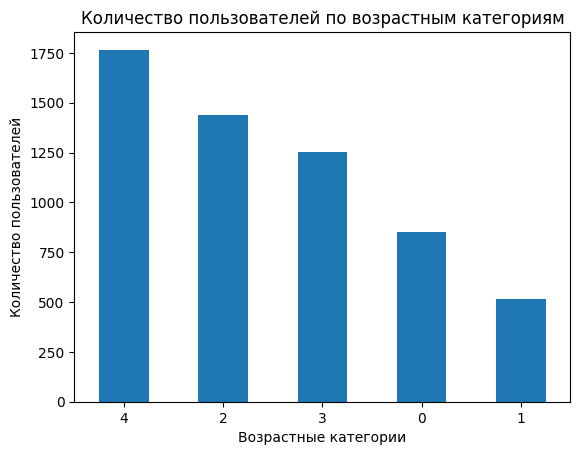

In [20]:
df_users['age_category'].value_counts().plot(
    kind='bar',
    rot = 0,
    title='Количество пользователей по возрастным категориям',
    xlabel='Возрастные категории',
    ylabel='Количество пользователей',
)
plt.show()

- 0: младше 18;
- 1: 18-25 лет;
- 2: 26-40 лет;
- 3: 41-55 лет;
- 4: 56+ лет.

Самый большой класс 4 - 56+ лет. Он в 4 раза больше, чем класс 1 - 18-25 лет. Таким образом мы имеем дело с умеренным дисбалансом классов.

### Анализ таблицы visits

In [21]:
df_visits.info()

<class 'pandas.DataFrame'>
RangeIndex: 1065745 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype
---  ------            --------------    -----
 0   date              1065745 non-null  str  
 1   daytime           1065745 non-null  str  
 2   session_id        1065745 non-null  str  
 3   user_id           1065745 non-null  str  
 4   website_category  1065745 non-null  str  
dtypes: str(5)
memory usage: 40.7 MB


Пропуски отсутствуют. Оценим дубликаты:

In [22]:
print(f'Количество полных дубликатов: {df_visits.duplicated().sum()}')

Количество полных дубликатов: 15750


Удалим дубликаты по user_id и по session_id.

In [23]:
drop_duplicates(df_visits)

Удалено 15750 строк (1.5%) из 1065745


In [24]:
df_visits.head(5)

,date,daytime,session_id,user_id,website_category
0,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 17
1,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 19
2,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 18
3,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 20
4,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 05


Проанализируем категориальные признаки website_category, daytime, session_id

In [25]:
users_by_website_cat = df_visits.groupby(['website_category']) \
    .agg(users_count=('user_id', 'nunique')) \
    .reset_index()
users_by_website_cat

,website_category,users_count
0,Category 01,5427
1,Category 02,5179
2,Category 03,4808
3,Category 04,5600
4,Category 05,5669
5,Category 06,5693
6,Category 07,5530
7,Category 08,5463
8,Category 09,5597
9,Category 10,5576


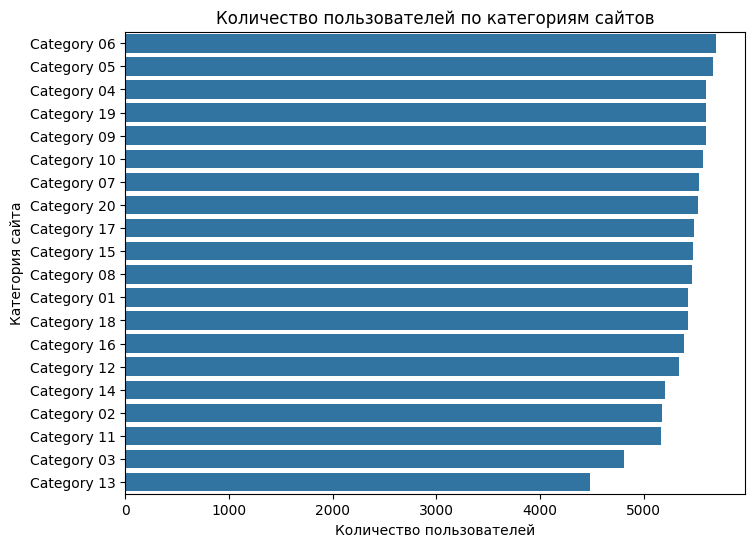

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(
    data=users_by_website_cat.sort_values('users_count', ascending=False),
    y='website_category',
    x='users_count',
    orient='h',
)
ax.set(
    title='Количество пользователей по категориям сайтов',
    ylabel='Категория сайта',
    xlabel='Количество пользователей',
)
plt.show()

Признак website_category содержит 20 категорий. Пропуски отсутствуют. Количество пользователей по категориям распределено почти равномерно - немного выделяются категории 3 и 12 - в них наибольшее количество. Категория 11 - самая малочисленная.

Данный признак необходимо кодировать с помощью TargetEncoder из-за высокой кардинальности.

Посмотрим теперь на категории сайтов в разрезе возрастных категорий:

In [27]:
# объединим таргет и таблицу с сессиями
df_user_visits_info = df_visits.merge(df_users, on='user_id')


age_category,0,1,2,3,4
website_category,,,,,
Category 01,789,509,1362,1205,1562
Category 02,766,506,1368,1117,1422
Category 03,797,267,1276,866,1602
Category 04,842,479,1337,1252,1690
Category 05,847,513,1366,1180,1763
Category 06,846,513,1388,1252,1694
Category 07,772,509,1437,1132,1680
Category 08,834,462,1436,1126,1605
Category 09,794,479,1313,1253,1758


age_category
0     853
1     514
2    1439
3    1254
4    1766
Name: user_id, dtype: int64

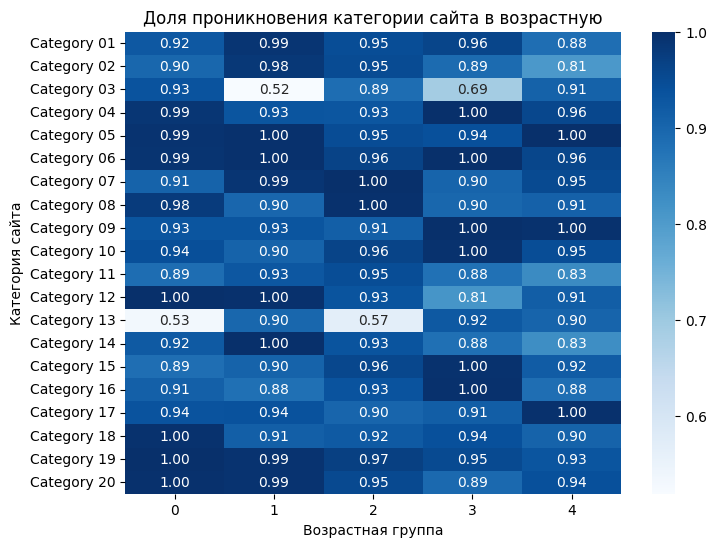

In [28]:

# количество уникальных пользователей по категории сайта и возрастной группе
pt = pd.pivot_table(
    df_user_visits_info,
    columns='age_category',
    index='website_category',
    values='user_id',
    aggfunc='nunique',
)
display(pt)

# размер каждой возрастной группы (всего уникальных пользователей)
age_group_sizes = df_users.groupby("age_category")["user_id"].nunique()
display(age_group_sizes)
# Нормализация по размеру группы (по столбцам)
pt_penetration = pt.div(age_group_sizes, axis=1)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pt_penetration,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    ax=ax,
)
ax.set(
    title='Доля проникновения категории сайта в возрастную',
    xlabel='Возрастная группа',
    ylabel='Категория сайта',

)
plt.show()

По тепловой карте видно, что некоторые категории менее интересны некоторым возрастным группам. Например, с категорией 13 знакомы только половина пользователей 0 и 1 возрастных категорий.

Рассчитаем долю каждой категории в пользовательских сессиях по пользователю.

In [29]:
df_website_cat_shares = (
    df_visits
    .groupby('user_id')['website_category']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .add_prefix('website_cat_share_')
    .reset_index()
)
df_website_cat_shares.head(5)

website_category,user_id,website_cat_share_Category 01,website_cat_share_Category 02,website_cat_share_Category 03,website_cat_share_Category 04,website_cat_share_Category 05,website_cat_share_Category 06,website_cat_share_Category 07,website_cat_share_Category 08,website_cat_share_Category 09,website_cat_share_Category 10,website_cat_share_Category 11,website_cat_share_Category 12,website_cat_share_Category 13,website_cat_share_Category 14,website_cat_share_Category 15,website_cat_share_Category 16,website_cat_share_Category 17,website_cat_share_Category 18,website_cat_share_Category 19,website_cat_share_Category 20
0,0010-5cf8f6b38a7b6c70a021-009dbcda,0.029304,0.000000,0.062271,0.042125,0.032967,0.053114,0.047619,0.075092,0.023810,0.040293,0.056777,0.078755,0.021978,0.034799,0.027473,0.060440,0.051282,0.078755,0.091575,0.091575
1,0013-4ae5f7d127b91a3fb0f8-ba59f141,0.081081,0.059459,0.027027,0.037838,0.081081,0.037838,0.048649,0.097297,0.059459,0.059459,0.070270,0.000000,0.064865,0.037838,0.016216,0.043243,0.064865,0.086486,0.005405,0.021622
2,0014-d3032d60979a8d2b3077-f09bdce8,0.008547,0.017094,0.034188,0.059829,0.068376,0.051282,0.042735,0.017094,0.034188,0.051282,0.000000,0.059829,0.170940,0.068376,0.059829,0.017094,0.076923,0.025641,0.102564,0.034188
3,001a-eee53e44f848608779b0-78704a67,0.066202,0.045296,0.034843,0.076655,0.034843,0.031359,0.041812,0.045296,0.045296,0.041812,0.048780,0.066202,0.000000,0.097561,0.041812,0.031359,0.045296,0.073171,0.073171,0.059233
4,002c-40a064b12e1217e12207-a56eaf3b,0.000000,0.053061,0.071429,0.061224,0.040816,0.038776,0.059184,0.018367,0.059184,0.065306,0.038776,0.085714,0.169388,0.000000,0.044898,0.040816,0.034694,0.012245,0.051020,0.055102


Можно использовать полученные значения как новые числовые признаки в случае недостаточного качества модели.

Теперь рассчитаем долю сессий пользователя в разное время суток.

In [30]:
df_time_shares = (
    df_visits
    .groupby('user_id')['daytime']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .add_prefix('daytime_share_')
    .reset_index()
)
df_time_shares.head(5)

daytime,user_id,daytime_share_вечер,daytime_share_день,daytime_share_ночь,daytime_share_утро
0,0010-5cf8f6b38a7b6c70a021-009dbcda,0.413919,0.326007,0.095238,0.164835
1,0013-4ae5f7d127b91a3fb0f8-ba59f141,0.275676,0.372973,0.086486,0.264865
2,0014-d3032d60979a8d2b3077-f09bdce8,0.307692,0.384615,0.094017,0.213675
3,001a-eee53e44f848608779b0-78704a67,0.414634,0.334495,0.108014,0.142857
4,002c-40a064b12e1217e12207-a56eaf3b,0.295918,0.383673,0.069388,0.251020


Посмотрим, как влияют найденные новые признаки на целевую переменную:

,user_id,age_category,website_cat_share_Category 01,website_cat_share_Category 02,website_cat_share_Category 03,website_cat_share_Category 04,website_cat_share_Category 05,website_cat_share_Category 06,website_cat_share_Category 07,website_cat_share_Category 08,website_cat_share_Category 09,website_cat_share_Category 10,website_cat_share_Category 11,website_cat_share_Category 12,website_cat_share_Category 13,website_cat_share_Category 14,website_cat_share_Category 15,website_cat_share_Category 16,website_cat_share_Category 17,website_cat_share_Category 18,website_cat_share_Category 19,website_cat_share_Category 20,daytime_share_вечер,daytime_share_день,daytime_share_ночь,daytime_share_утро
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4,0.064171,0.037433,0.037433,0.058824,0.101604,0.021390,0.000000,0.048128,0.101604,0.026738,0.074866,0.016043,0.032086,0.037433,0.053476,0.042781,0.058824,0.069519,0.074866,0.042781,0.336898,0.358289,0.074866,0.229947
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2,0.063830,0.042553,0.099291,0.021277,0.056738,0.035461,0.106383,0.106383,0.042553,0.070922,0.042553,0.042553,0.035461,0.000000,0.063830,0.035461,0.035461,0.028369,0.035461,0.035461,0.390071,0.340426,0.092199,0.177305
2,678b-614cd47d854b9d591db2-000b2e50,0,0.010000,0.070000,0.000000,0.110000,0.070000,0.130000,0.000000,0.040000,0.000000,0.010000,0.030000,0.150000,0.120000,0.010000,0.020000,0.030000,0.020000,0.010000,0.110000,0.060000,0.380000,0.290000,0.130000,0.200000
3,4ac0-dad169100b4a29b20818-b26ae7c5,4,0.080645,0.004032,0.100806,0.028226,0.108871,0.048387,0.028226,0.064516,0.060484,0.000000,0.064516,0.016129,0.076613,0.020161,0.024194,0.028226,0.064516,0.133065,0.036290,0.012097,0.258065,0.439516,0.072581,0.229839
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0,0.067227,0.042017,0.092437,0.033613,0.050420,0.008403,0.050420,0.067227,0.075630,0.042017,0.042017,0.126050,0.000000,0.084034,0.025210,0.025210,0.050420,0.033613,0.025210,0.058824,0.420168,0.344538,0.075630,0.159664


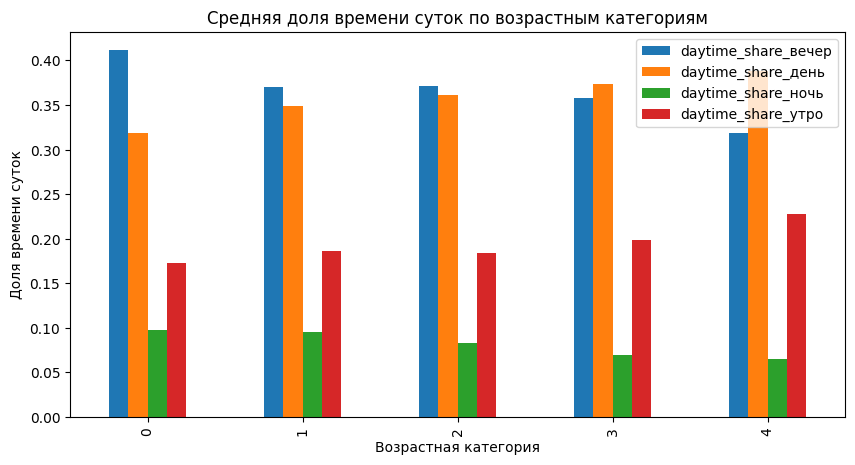

In [31]:
merged = df_users \
    .merge(df_website_cat_shares, on='user_id') \
    .merge(df_time_shares, on='user_id')
display(merged.head(5))

float_features = merged.select_dtypes(['float64']).columns.to_list()

means_by_age = merged[float_features + ['age_category']].groupby('age_category').mean()

website_cat_share_columns = [x for x in means_by_age.columns if x.startswith('website_cat_share_')]
daytime_share_columns = [x for x in means_by_age.columns if x.startswith('daytime_share_')]
means_by_age[daytime_share_columns].reset_index().plot(
    x='age_category',
    y=daytime_share_columns,
    kind='bar',
    xlabel='Возрастная категория',
    ylabel='Доля времени суток',
    title='Средняя доля времени суток по возрастным категориям',
    figsize=(10, 5)
)
plt.show()

На графике хорошо видно, что чем старше пользователи, тем ночь становится менее популярным временем выхода в интернет и утро становится более востребованным для этой цели.

Данная группа признаков должна дать хороший прирост качества модели.


Оценим общее время активности пользователей в датасете.

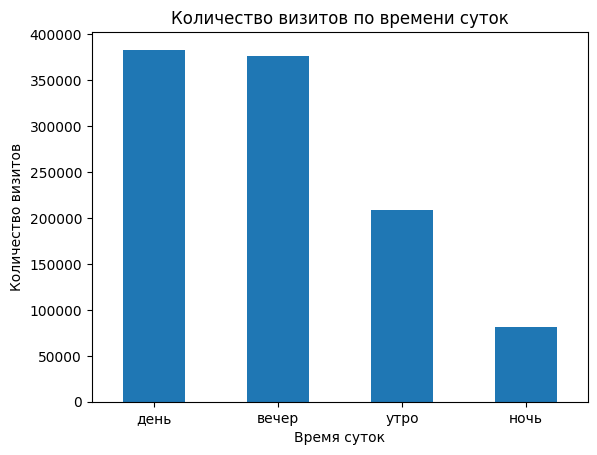

In [32]:
df_visits['daytime'].value_counts(dropna=False).plot(
    kind='bar',
    title='Количество визитов по времени суток',
    xlabel='Время суток',
    ylabel='Количество визитов',
    rot=0
)
plt.show()

Ночь и утро - самое малоактивное время. Пропусков нет.

Как идея для новых признаков:
- можно считать количество сессий в разрезе времени суток для каждого пользователя с усреднением по неделе. 
- наиболее популярное время суток для каждого пользователя

In [33]:
df_visits['session_id'].nunique()

1049995

Столбец session_id содержит 1 млн значений. Он технический (не применяется для непосредственного обучения модели) и может быть использован для агрегации информации, например, по количеству сессий пользователя в среднем за неделю.



In [34]:
df_visits['user_id'].nunique()

5826

В таблице представлена информация о почти ~5800 пользователей. Проверим, что это те же пользователи, что и в таблице users:

In [35]:
set(df_visits['user_id'].unique()) == set(df_users['user_id'].unique())

True

Это одинаковые пользователи - таким образом проверили, что не будет проблем при объединении.

В качестве примера агрегации таблици visits, рассчитаем количество сессий каждого пользователя за 2 недели:

In [36]:
df_users_from_visits = df_visits.groupby('user_id').agg(
    session_count = ('session_id', 'count'),
).reset_index()
df_users_from_visits
df_users.merge(df_users_from_visits, on='user_id', how='right').head(5)

,user_id,age_category,session_count
0,0010-5cf8f6b38a7b6c70a021-009dbcda,0,546
1,0013-4ae5f7d127b91a3fb0f8-ba59f141,4,185
2,0014-d3032d60979a8d2b3077-f09bdce8,4,117
3,001a-eee53e44f848608779b0-78704a67,0,287
4,002c-40a064b12e1217e12207-a56eaf3b,4,490


### Анализ таблицы ads_activity

In [37]:
df_ads_activity.info()

<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5826 non-null   str  
 1   ads_activity  5826 non-null   str  
dtypes: str(2)
memory usage: 91.2 KB


Пропусков нет. Оценим дубликаты и удалим при наличии:

In [38]:
drop_duplicates(df_ads_activity, subset=['user_id'])

Удалено 233 строк (4.0%) из 5826


Теперь значений user_id в таблице ads_activity меньше, чем в таблице users - при объединении с профилем пользователей нужно будет заполнять пропуски. Заполним их модой в разрезе возрастной группы или удалим - решим при объединении датасетов.

### Анализ таблицы df_surf_depth


In [39]:
df_surf_depth.info()

<class 'pandas.DataFrame'>
RangeIndex: 5715 entries, 0 to 5714
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     5715 non-null   str  
 1   surf_depth  5715 non-null   str  
dtypes: str(2)
memory usage: 89.4 KB


Пропусков нет. Удалим дубликаты при наличии:

In [40]:
drop_duplicates(df_surf_depth, subset=['user_id'])

Дубликатов не обнаружено


Дубликатов нет, но пользователей меньше, чем в таблице df_users: пропуски будем заменять модами в разрезе возрастной группы или удалим строки с пропусками.

In [41]:
df_surf_depth['surf_depth'].value_counts()

surf_depth
средне          2435
поверхностно    2424
глубоко          856
Name: count, dtype: int64

В столбце surf_depth представлено 3 категории. Неявных дубликатов нет.

### Анализ таблицы df_primary_device


In [42]:
df_primary_device.info()

<class 'pandas.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   user_id         5669 non-null   str  
 1   primary_device  5669 non-null   str  
dtypes: str(2)
memory usage: 88.7 KB


In [43]:
drop_duplicates(df_primary_device, subset=['user_id'])

Дубликатов не обнаружено


Дубликатов и пропусков нет.

При объединении датасетов девайс будем заполнять модой по возрастной группе или удалим строки.

### Анализ таблицы df_cloud_usage

In [44]:
df_cloud_usage.info()

<class 'pandas.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      5680 non-null   str  
 1   cloud_usage  5680 non-null   bool 
dtypes: bool(1), str(1)
memory usage: 50.1 KB


In [45]:
drop_duplicates(df_cloud_usage, subset=['user_id'])

Дубликатов не обнаружено


Дубликатов и пропусков нет. При объединении пропуски будем заполнять модой по возрастной группе или удалим.

### Объединение таблиц в датасет

Объединим все предоставленные таблицы в единый датасет для обучения. Необходимо решить несколько задач:

1. Агрегировать таблицу visits по пользователю
2. Заполнить пропуски или удалить строки с пропусками - в зависимости от количества пропусков

Выделим из таблицы visits следующие агрегаты по пользователю:
- `preferable_daytime` - предпочтительное время выхода пользователя в интернет
- `preferable_website_cat` - предпочтительная категория посещаемых сайтов
- `mean_session_count_per_1d` - среднее количество сессий пользователя в день

Сохраним способ объединения датасетов и создания признаков в отдельном классе, чтобы переиспользовать его для применения модели в продакшене:

In [46]:
class DfUserProfileMaker:
    def __init__(self):
        pass

    def make_df_user_visits_(self, df_visits):
        # определим метод для возврата одной моды в случае если их несколько
        def only_one_mode(x):
            return pd.Series.mode(x)[0]

        # собираем признаки по df_visits

        # preferable_daytime, preferable_website_cat, session_count_2w
        df_user_visits = df_visits.groupby('user_id').agg(
            preferable_daytime = ('daytime', only_one_mode),
            preferable_website_cat = ('website_category', only_one_mode),
        ).reset_index()

        # mean_session_count_per_1d
        ftr_name_session_count_per_1d = 'mean_session_count_per_1d'
        df_user_by_mean_session_count_per_1d = df_visits.groupby(['user_id', 'date']).agg(
            session_count_per_1d = ('session_id', 'count')
        ).reset_index().groupby('user_id').agg(
            mean_session_count_per_1d=('session_count_per_1d', 'mean')
        )
        df_user_visits = df_user_visits \
            .merge(df_user_by_mean_session_count_per_1d, on='user_id')
        return df_user_visits

    def make_df_user_profile(self, df_users, df_visits, df_ads_activity,
                             df_surf_depth, df_primary_device, df_cloud_usage):
        df_user_visits = self.make_df_user_visits_(df_visits)
        df = df_users.merge(df_user_visits, on='user_id', how='left')
        df = df.merge(df_ads_activity, on='user_id', how='left') \
            .merge(df_surf_depth, on='user_id', how='left') \
            .merge(df_primary_device, on='user_id', how='left') \
            .merge(df_cloud_usage, on='user_id', how='left')
        return df

    def merge_additional_features(self, df, df_visits):
        # рассчитываем пользовательский признак website_cat_share_*
        df_website_cat_shares = (
            df_visits
                .groupby('user_id')['website_category']
                .value_counts(normalize=True)
                .unstack(fill_value=0)
                .add_prefix('website_cat_share_')
                .reset_index()
        )
        # в случае отсутствия в group by у пользователя категории - добавим с 0
        all_cat_cols = [f'website_cat_share_Category {i:02d}' for i in range(1, 21)]
        df_website_cat_shares = df_website_cat_shares.reindex(
            columns=['user_id'] + all_cat_cols, fill_value=0
        )
        # рассчитываем пользовательский признак daytime_share_*
        df_time_shares = (
            df_visits
                .groupby('user_id')['daytime']
                .value_counts(normalize=True)
                .unstack(fill_value=0)
                .add_prefix('daytime_share_')
                .reset_index()
        )
        merged = df \
            .merge(df_website_cat_shares, on='user_id') \
            .merge(df_time_shares, on='user_id')
        return merged


Объединим все остальные признаки:

In [47]:
user_profile_maker = DfUserProfileMaker()
df = user_profile_maker.make_df_user_profile(
    df_users, df_visits, df_ads_activity, df_surf_depth,
    df_primary_device, df_cloud_usage
)

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    5826 non-null   str    
 1   age_category               5826 non-null   int64  
 2   preferable_daytime         5826 non-null   str    
 3   preferable_website_cat     5826 non-null   str    
 4   mean_session_count_per_1d  5826 non-null   float64
 5   ads_activity               5593 non-null   str    
 6   surf_depth                 5715 non-null   str    
 7   primary_device             5669 non-null   str    
 8   cloud_usage                5680 non-null   object 
dtypes: float64(1), int64(1), object(1), str(6)
memory usage: 409.8+ KB


Получили датасет из ~5800 объектов, состоящих из 8-ми признаков. Все признаки за исключением mean_session_count_per_1d - категориальные. Проверим, числовой признак на аномалии:

In [49]:
TARGET='age_category'


       mean_session_count_per_1d
count                5826.000000
mean                   12.874047
std                     5.369733
min                     7.142857
25%                     8.857143
50%                    11.928571
75%                    15.214286
max                    59.928571


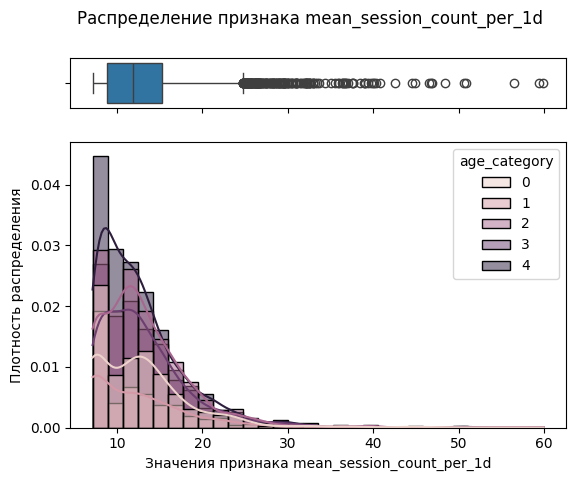

In [50]:
box_hist(df, 'mean_session_count_per_1d', bins=30, hue=TARGET)

Распределение имеет правое смещение. Имеются выбросы, когда пользователь совершил более 400 сессий за 2 недели, но это примерно 30 сессий в день, что для современного человека с СДВГ не так уж и много. Аномалии не требуют обработки.

Оценим пропуски в получившейся таблице:

In [51]:
na_info(df)


,index,Количество строк,Количество пропусков,Процент пропусков
0,ads_activity,5826,233,4.0
1,primary_device,5826,157,2.7
2,cloud_usage,5826,146,2.5
3,surf_depth,5826,111,1.9


Подготовим функцию, которая позволит заменить пропущенные значения в указанных категориальных признаках на моду по возрастной группе.

In [52]:
df_modes = df.groupby(['age_category']).agg(
    ads_activity = ('ads_activity', pd.Series.mode),
    primary_device = ('primary_device', pd.Series.mode),
    cloud_usage = ('cloud_usage', pd.Series.mode),
    surf_depth = ('surf_depth', pd.Series.mode),
).reset_index().reset_index(drop=True).to_dict()

def fill_na(row):
    age_cat = row['age_category']

    def fill_cat(cat_name):
        if row[cat_name] is np.nan:
            row[cat_name] = df_modes[cat_name][age_cat]

    for na_cat in df_modes.keys():
        fill_cat(na_cat)

    return row

# df = df.apply(fill_na, axis=1)
# na_info(df)


Итого, мы имеем порядка 10% пропусков в датасете - по сумме процентов по каждому признаку. Можно восстановить эти пропуски, но данных для обучения достаточно, поэтому просто удалим их. В случае необходимости повысить качество модели - займемся их восстановлением.

In [53]:
df_orig = df.copy()

In [54]:
df.dropna(inplace=True)
diff = len(df_orig) - len(df)
diff_pct = diff / len(df_orig) * 100
print(f'Удалено {diff} строк ({diff_pct:.1f}%) из {len(df_orig)}')

Удалено 621 строк (10.7%) из 5826


На данном этапе были объединены все таблицы в один датасет профилей пользователей. Восстановлены пропуски в датасете модами в разрезе возрастных групп. Добавлено минимальное количество признаков по агрегированной информацией с событиями посещений сайтов.

### Корреляционный анализ

Оценим взаимосвязь признаков и связь признаков с целевой переменной.

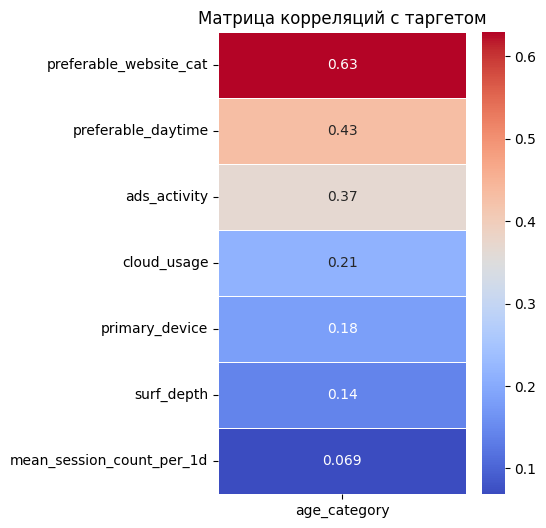

In [55]:
interval_cols = df.select_dtypes(include=['int64', 'float64']).columns
interval_cols = interval_cols.drop(TARGET)
full_corr_matrix = df.drop(columns=['user_id']).phik_matrix(interval_cols=interval_cols)
corr_displayer = CorrelationDisplayer(full_corr_matrix)
corr_displayer.draw_corr_matrix_with_target(TARGET, figsize=(4, 6))

Сильная корреляция с целевой переменной, как и ожидалось, в категориях посещенных сайтов а также среднаяя корреляция со временем выхода в интернет. Умеренная корреляция со статусом активности взаимодействия с рекламой. Почти нулевая корреляция с количеством сессий в день. Выглядит, что этот признак бесполезен.

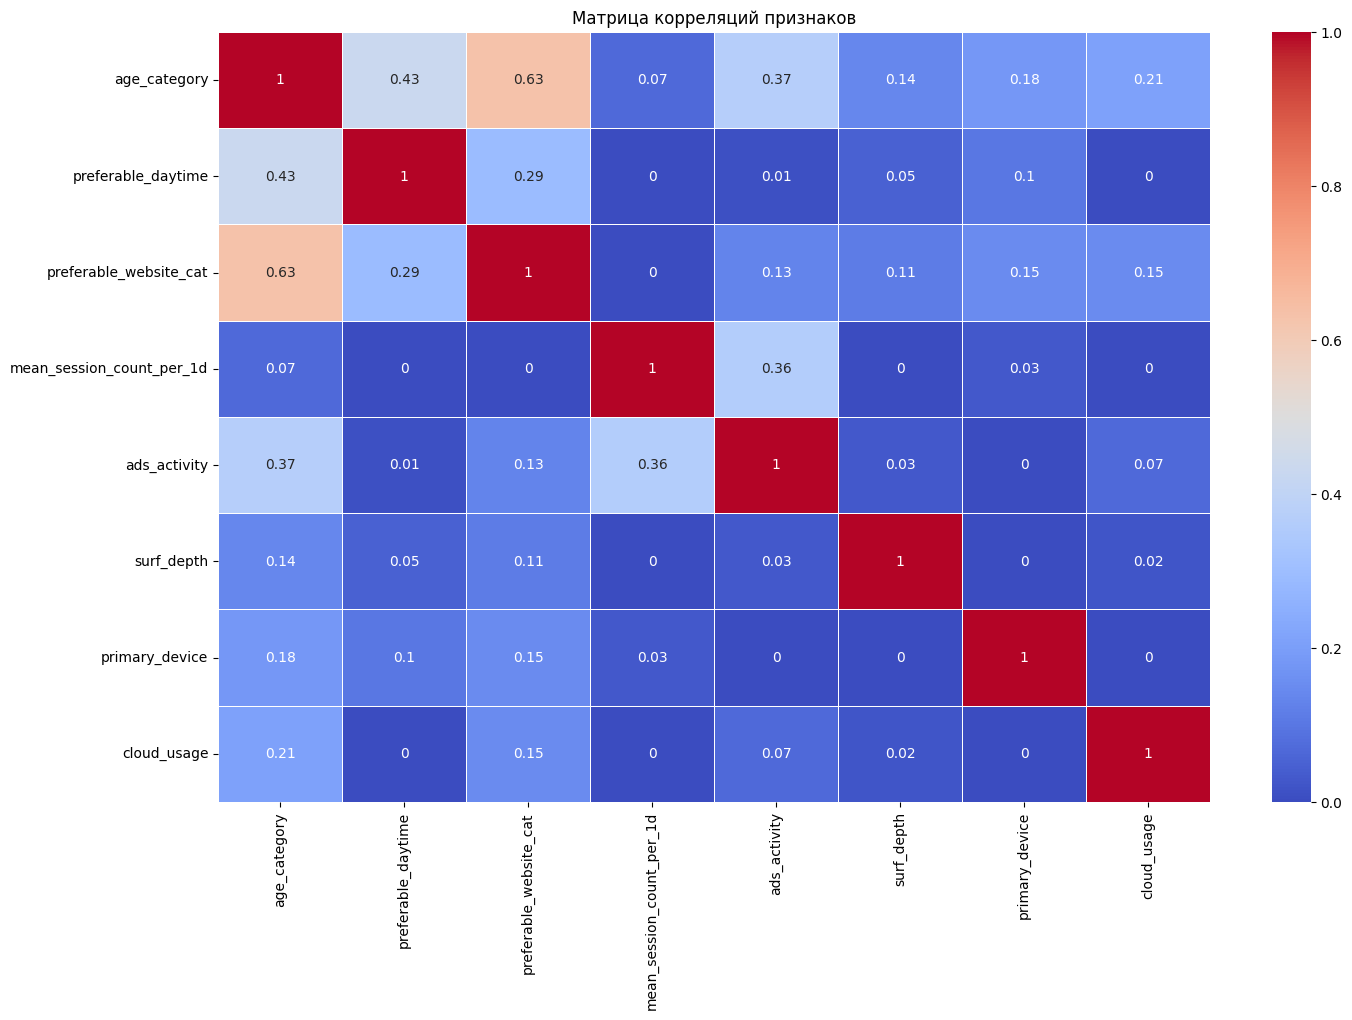

In [56]:
corr_displayer.draw_corr_matrix_full()

Наблюдаются корреляции между признакамми доли посещений категорий сайтов с предпочтительной категорией. Это ожидаемо.

### Вывод по EDA

Датасет сформирован из нескольких источников и насчитывает около 5000 объектов, что достаточно для обучения линейной модели.

Около 10% объектов были выброшены из-за наличия пропусков и как дубликаты.

По таблице visits сформированы несколько признаков доля категории вебсайта в пользовательских сессиях и доля времени суток в пользовательских сессиях. Корреляционный анализ показывает, что это должны быть полезные признаки для целевой переменной.

<a id="preprocessing"></a>

## Предобработка данных

In [57]:
df.info()

<class 'pandas.DataFrame'>
Index: 5205 entries, 1 to 5824
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    5205 non-null   str    
 1   age_category               5205 non-null   int64  
 2   preferable_daytime         5205 non-null   str    
 3   preferable_website_cat     5205 non-null   str    
 4   mean_session_count_per_1d  5205 non-null   float64
 5   ads_activity               5205 non-null   str    
 6   surf_depth                 5205 non-null   str    
 7   primary_device             5205 non-null   str    
 8   cloud_usage                5205 non-null   object 
dtypes: float64(1), int64(1), object(1), str(6)
memory usage: 406.6+ KB


In [58]:
# Удаляем технические столбцы:
TECHNICAL_COLS = ['user_id']

Разобъем датасет на выборки. Будем использовать кросс-валидацию, поэтому разбивать будем на тренировочный и тестовый датасет. Кросс-валидация под капотом разобъет тренировочный датасет на train и val.

In [59]:
X = df.drop(columns=[TARGET] + TECHNICAL_COLS)
y = df[TARGET]

In [60]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=y,
)

In [61]:
print(f'Доля классов в полном датасете:')
print((y.value_counts() / len(y)).round(2))
print(f'Доля классов в тренировочной выборке:')
print((y_train_val.value_counts() / len(y_train_val)).round(2))
print(f'Доля классов в тестовой выборке:')
print((y_test.value_counts() / len(y_test)).round(2))

Доля классов в полном датасете:
age_category
4    0.30
2    0.24
3    0.22
0    0.15
1    0.09
Name: count, dtype: float64
Доля классов в тренировочной выборке:
age_category
4    0.30
2    0.24
3    0.22
0    0.15
1    0.09
Name: count, dtype: float64
Доля классов в тестовой выборке:
age_category
4    0.30
2    0.24
3    0.22
0    0.15
1    0.09
Name: count, dtype: float64


Пропорции классов соблюдены во всех выборках.

Определим фичи в списки в зависимости от типа предобработки.

In [62]:
OHE_FEATURES = [
    'preferable_daytime',
    'ads_activity',
    'surf_depth',
    'primary_device',
]
TARGET_ENCODED_FEATURES = [
    'preferable_website_cat',
]
NUM_FEATURES = [
    'cloud_usage',
] + df.select_dtypes(['float64']).columns.to_list()

Определим пайплайн трансформации данных для числовых и категориальных признаков с OHE/TargetEncoding-кодированием: 

In [63]:

cv_nsplits = 5

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    # не используем, так как Scaler имеется в финальном пайплайне
    # для масштабирования всех признаков, в т.ч. закодированных категориальных
    # upd: все таки используем, иначе испортим OHE-признаки
    ('scaler', StandardScaler()),
])

cat_ohe_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(
        sparse_output=False,
        drop='first', # для избегания Dummy ловушки
        handle_unknown='ignore',
    )),
])

cat_te_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('enc', TargetEncoder(
        target_type='multiclass',
        shuffle=True,
        random_state=RANDOM_STATE,
        cv=cv_nsplits, # для предотвращения data leakage
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat_ohe', cat_ohe_pipeline, OHE_FEATURES),
        ('cat_te', cat_te_pipeline, TARGET_ENCODED_FEATURES),
        ('num', num_pipeline, NUM_FEATURES),
    ]
)
##
# Определим утилиты для создания моделей и пайплайнов
##
def pipe(estimator, mcc=None, preproc=None):
    """
    mcc -- [ovo, ovr, None] - стратегия создания бинклассификаторов
    для multi class classification
    """
    if mcc == 'ovo':
        estimator = OneVsOneClassifier(estimator)
    if mcc == 'ovr':
        estimator = OneVsRestClassifier(estimator)
    return Pipeline([
        ('preprocessor', preprocessor if preproc is None else preproc),
        # upd: не используем, иначе испортим OHE-признаки
        # ('common_scaler', StandardScaler()),
        ('estimator', estimator)
    ])

def logreg(**kwargs):
    return LogisticRegression(
        random_state=RANDOM_STATE,
        class_weight='balanced',
        **kwargs,
    )

def svm(tol=0.01, **kwargs):
    return SVC(
        random_state=RANDOM_STATE,
        class_weight='balanced',
        tol=tol,
        max_iter=-1,
        **kwargs,
    )

<a id="baseline"></a>

## Обучение и оценка базовой модели

In [64]:
# Определим пайплайны с разными архитектурами моделей
pipelines = {
    'logreg': pipe(logreg()),
    'logreg_ovo': pipe(logreg(), mcc='ovo'),
    'logreg_ovr': pipe(logreg(), mcc='ovr'),
    'svm_lin': pipe(svm(kernel='linear')),
    'svm_lin_ovo': pipe(svm(kernel='linear'), mcc='ovo'),
    'svm_poly': pipe(svm(kernel='poly')),
    'svm_poly_d2': pipe(svm(kernel='poly', degree=2)),
    'svm_poly_ovo': pipe(svm(kernel='poly'), mcc='ovo'),
    'svm_poly_ovr': pipe(svm(kernel='poly'), mcc='ovr'),
    'svm_poly_ovr_d2': pipe(svm(kernel='poly', degree=2), mcc='ovr'),
    'svm_rbf': pipe(svm(kernel='rbf')),
    'svm_rbf_ovo': pipe(svm(kernel='rbf'), mcc='ovo'),
    'svm_rbf_ovr': pipe(svm(kernel='rbf'), mcc='ovr'),
    'svm_sig': pipe(svm(kernel='sigmoid', coef0=1, gamma='scale')),
    'svm_sig_ovo': pipe(svm(kernel='sigmoid', coef0=1, gamma='scale'), mcc='ovo'),
    'svm_sig_ovr': pipe(svm(kernel='sigmoid', coef0=1, gamma='scale'), mcc='ovr'),
    'dummy': DummyClassifier(strategy='stratified'),
}


scoring = ['f1_macro', 'precision_macro', 'recall_macro']

# Используем статифицированный кросс валидатор для учета балансов классов
skf = StratifiedKFold(n_splits=cv_nsplits, shuffle=True, random_state=RANDOM_STATE)
metrics_df_list = []
cv_results = do_cross_validation(
    pipelines, X_train_val, y_train_val, scoring, metrics_df_list, cv=skf)
cv_results

,model_name,f1_macro,precision_macro,recall_macro
0,svm_rbf_ovr,0.484,0.479,0.497
1,svm_poly_ovr_d2,0.472,0.470,0.488
2,logreg,0.471,0.470,0.488
3,svm_poly_ovr,0.471,0.469,0.483
4,logreg_ovo,0.469,0.468,0.486
5,svm_lin,0.467,0.469,0.488
6,svm_lin_ovo,0.465,0.467,0.483
7,svm_rbf_ovo,0.461,0.462,0.483
8,logreg_ovr,0.460,0.459,0.481
9,svm_poly_d2,0.459,0.463,0.486


In [65]:
# сохраним результато бейзлайн модели в переменную для сравнения
baseline_f1_macro = cv_results.iloc[0]['f1_macro']
print(f'Метрика бейзлайн модели: {baseline_f1_macro:.3f}')

Метрика бейзлайн модели: 0.484


Целевая метрика базовой модели $f1_{macro} = 0.48$ для SVM с ядром rbf и подходом обучения бинарных классификаторов One-vs-Rest, что хорошо для первого подхода.


Оценим матрицу ошибок для логрега (тоже одна из лучших моделей, нам нужны ее коэффициенты для оценки важности признаков).

              precision    recall  f1-score   support

           0       0.55      0.62      0.59       138
           1       0.24      0.35      0.28        72
           2       0.55      0.40      0.47       211
           3       0.34      0.33      0.34       182
           4       0.65      0.69      0.67       230

    accuracy                           0.50       833
   macro avg       0.47      0.48      0.47       833
weighted avg       0.51      0.50      0.50       833



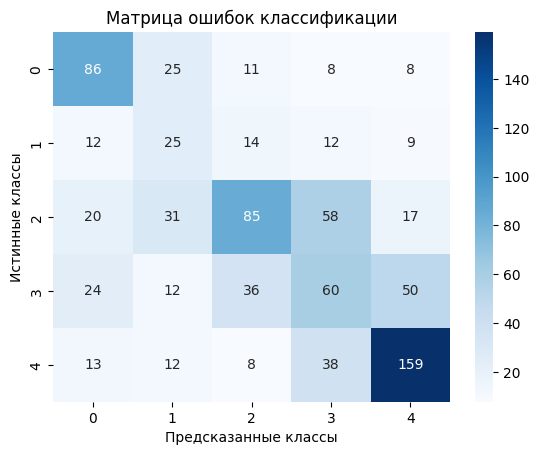

In [66]:
pipeline = pipe(logreg())
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.2,
    random_state=RANDOM_STATE,
)
pipeline.fit(X_train, y_train)
y_pred_val = pipeline.predict(X_val)

print(classification_report(y_val, y_pred_val, digits=2))

ax = sns.heatmap(
    confusion_matrix(y_val, y_pred_val),
    annot=True,
    cmap='Blues',
    fmt='d',
)
ax.set(
    xlabel='Предсказанные классы',
    ylabel='Истинные классы',
    title='Матрица ошибок классификации',
)
plt.show()


- 0: младше 18;
- 1: 18-25 лет;
- 2: 26-40 лет;
- 3: 41-55 лет;
- 4: 56+ лет.

По матрице ошибок и отчету классификации можно сделать следующий вывод:
- лучше всего классифицируется группа 4 (56+ лет)- это самый широкий класс в выборке.
- 3 класс сильно спутывается с 2 и 4
- 2 класс спутывается с 3
- класс 0 распознается относительно неплохо
- класс 1 имеет самые слабые метрики классификации - это самый малочисленный класс

Посмотрим на важность признаков:

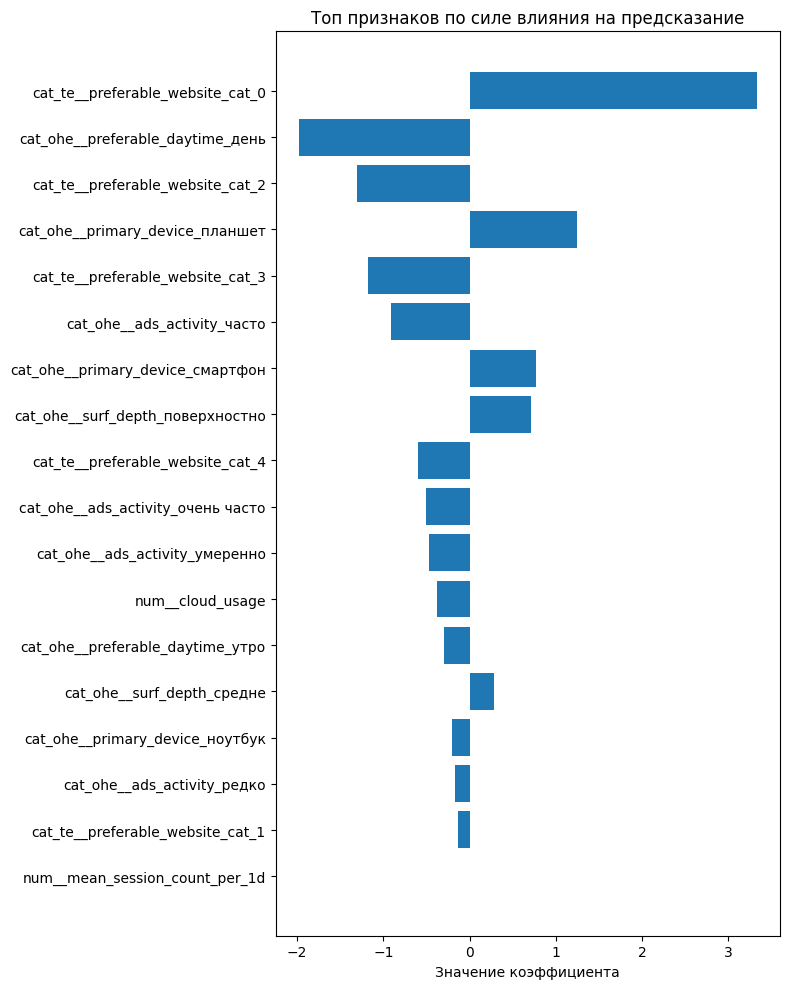

,feature,coefficient,abs_coefficient
0,cat_te__preferable_website_cat_0,3.332693,3.332693
1,cat_ohe__preferable_daytime_день,-1.983577,1.983577
2,cat_te__preferable_website_cat_2,-1.301914,1.301914
3,cat_ohe__primary_device_планшет,1.247726,1.247726
4,cat_te__preferable_website_cat_3,-1.173949,1.173949
5,cat_ohe__ads_activity_часто,-0.908923,0.908923
6,cat_ohe__primary_device_смартфон,0.765514,0.765514
7,cat_ohe__surf_depth_поверхностно,0.712057,0.712057
8,cat_te__preferable_website_cat_4,-0.600776,0.600776
9,cat_ohe__ads_activity_очень часто,-0.507907,0.507907


In [67]:
feature_importance(pipeline['estimator'], pipeline[:-1].get_feature_names_out())['weights']

Хорошая новость - добавленные признаки preferable_website_cat, preferable_daytime - в топе по полезности для логистической регрессии.
Но другой добавленный признак - среднее количество сессий в сутки - не оказывает почти никакого влияния на предсказания модели.

<a id="feature-engineering"></a>

## Создание и отбор признаков

Как мы выяснили в разделе EDA, полезными признаками являются производные от категорий сайтов и времени пребывания в интернете. Добавим исследованные признаки в датасет. Кроме того, признак связанный со временем посещения выглядит очень полезным для модели. 

Следовательно, добавим рассмотренные в разделе EDA признаки в модель.

В связи с тем, что исходная задача не подразумевает вычисления категории возраста в рантайме (то есть вычисление данного признака будет происходить в офлайн процессах, не связанных с обработкой пользовательских запросов), вычисление перенесем в исходный датасет, не прибегая к модификации Pipeline.

Отметим также, так как для подсчета новых признаков используется статистика по пользователю, а датасет в последствие разбивается на train_val и test тоже по пользователю, то тут не происходит data leakage. В случае, если бы статистики, на основе которых вычисляются новые признаки, вычислялись по всему датасету, то произошел бы data leakage.

In [68]:
df = user_profile_maker.merge_additional_features(df, df_visits)
display(df.head(5))
df.info()

,user_id,age_category,preferable_daytime,preferable_website_cat,mean_session_count_per_1d,ads_activity,surf_depth,primary_device,cloud_usage,website_cat_share_Category 01,website_cat_share_Category 02,website_cat_share_Category 03,website_cat_share_Category 04,website_cat_share_Category 05,website_cat_share_Category 06,website_cat_share_Category 07,website_cat_share_Category 08,website_cat_share_Category 09,website_cat_share_Category 10,website_cat_share_Category 11,website_cat_share_Category 12,website_cat_share_Category 13,website_cat_share_Category 14,website_cat_share_Category 15,website_cat_share_Category 16,website_cat_share_Category 17,website_cat_share_Category 18,website_cat_share_Category 19,website_cat_share_Category 20,daytime_share_вечер,daytime_share_день,daytime_share_ночь,daytime_share_утро
0,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2,вечер,Category 07,10.071429,умеренно,средне,смартфон,False,0.063830,0.042553,0.099291,0.021277,0.056738,0.035461,0.106383,0.106383,0.042553,0.070922,0.042553,0.042553,0.035461,0.000000,0.063830,0.035461,0.035461,0.028369,0.035461,0.035461,0.390071,0.340426,0.092199,0.177305
1,678b-614cd47d854b9d591db2-000b2e50,0,вечер,Category 12,7.142857,умеренно,средне,смартфон,False,0.010000,0.070000,0.000000,0.110000,0.070000,0.130000,0.000000,0.040000,0.000000,0.010000,0.030000,0.150000,0.120000,0.010000,0.020000,0.030000,0.020000,0.010000,0.110000,0.060000,0.380000,0.290000,0.130000,0.200000
2,4ac0-dad169100b4a29b20818-b26ae7c5,4,день,Category 18,17.714286,редко,поверхностно,смартфон,True,0.080645,0.004032,0.100806,0.028226,0.108871,0.048387,0.028226,0.064516,0.060484,0.000000,0.064516,0.016129,0.076613,0.020161,0.024194,0.028226,0.064516,0.133065,0.036290,0.012097,0.258065,0.439516,0.072581,0.229839
3,f19b-9ac21ca973b41ecfa8c3-6a58191d,0,вечер,Category 12,8.500000,очень редко,поверхностно,смартфон,True,0.067227,0.042017,0.092437,0.033613,0.050420,0.008403,0.050420,0.067227,0.075630,0.042017,0.042017,0.126050,0.000000,0.084034,0.025210,0.025210,0.050420,0.033613,0.025210,0.058824,0.420168,0.344538,0.075630,0.159664
4,348c-35488a73fb49d5b0449e-1920481e,0,вечер,Category 14,7.142857,умеренно,поверхностно,смартфон,False,0.080000,0.010000,0.090000,0.080000,0.010000,0.060000,0.050000,0.050000,0.030000,0.010000,0.000000,0.080000,0.000000,0.130000,0.070000,0.050000,0.000000,0.090000,0.060000,0.050000,0.480000,0.270000,0.150000,0.100000


<class 'pandas.DataFrame'>
RangeIndex: 5205 entries, 0 to 5204
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   user_id                        5205 non-null   str    
 1   age_category                   5205 non-null   int64  
 2   preferable_daytime             5205 non-null   str    
 3   preferable_website_cat         5205 non-null   str    
 4   mean_session_count_per_1d      5205 non-null   float64
 5   ads_activity                   5205 non-null   str    
 6   surf_depth                     5205 non-null   str    
 7   primary_device                 5205 non-null   str    
 8   cloud_usage                    5205 non-null   object 
 9   website_cat_share_Category 01  5205 non-null   float64
 10  website_cat_share_Category 02  5205 non-null   float64
 11  website_cat_share_Category 03  5205 non-null   float64
 12  website_cat_share_Category 04  5205 non-null   float64
 13 

Оценим корреляции признаков друг с другом чтобы выбрать кандидатов на отбор.

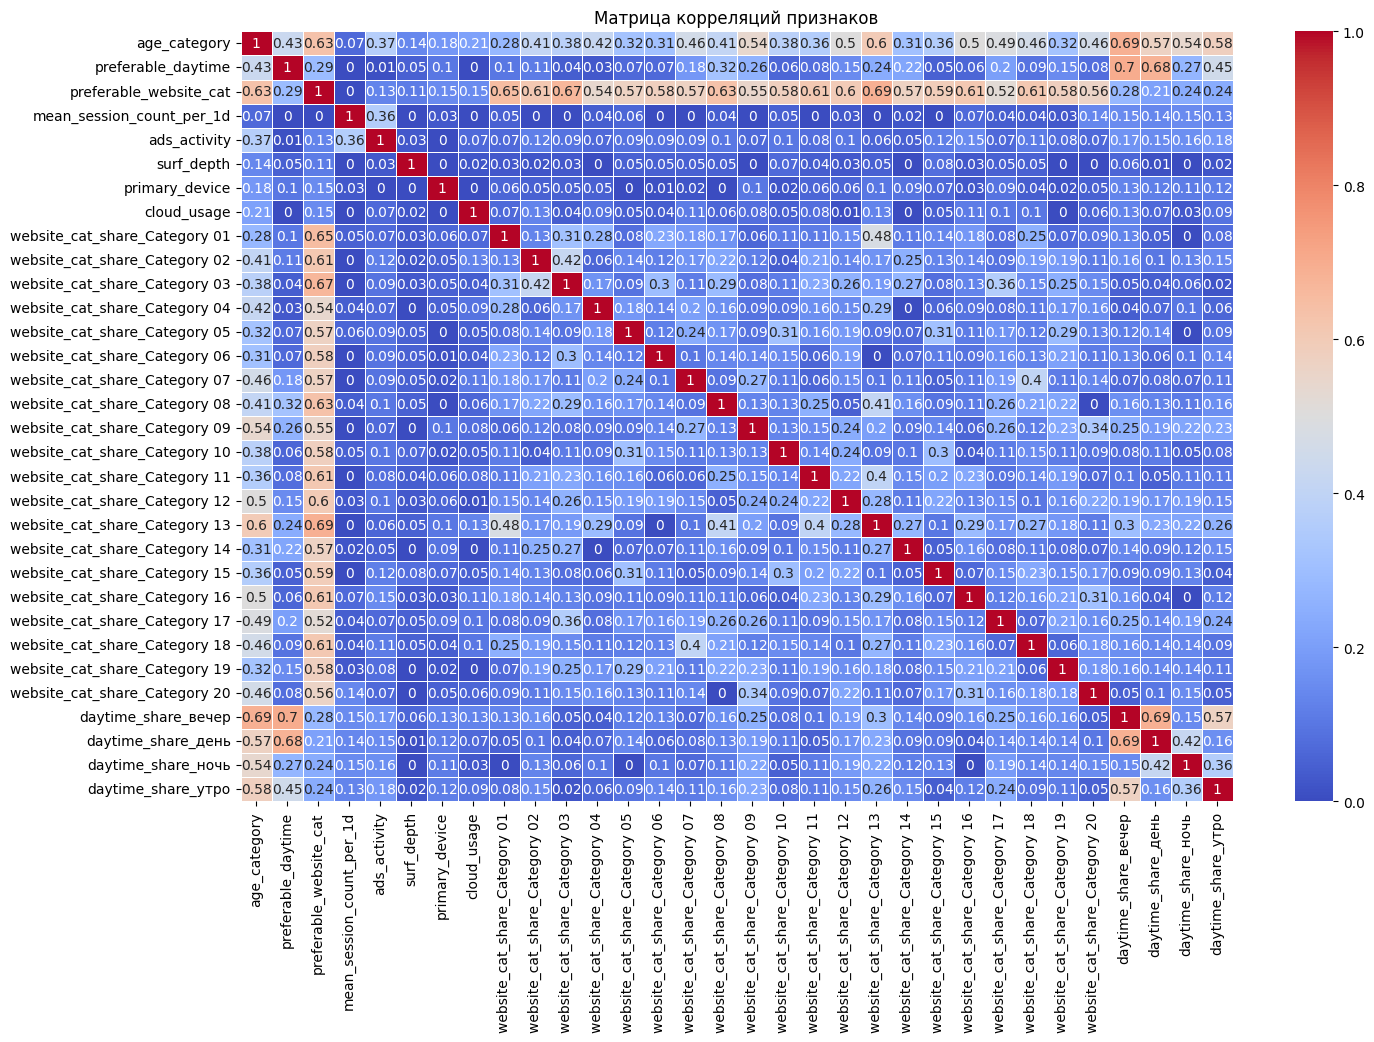

In [69]:
interval_cols = df.select_dtypes(include=['float64']).columns
full_corr_matrix = df.drop(columns=['user_id']).phik_matrix(interval_cols=interval_cols)
corr_displayer = CorrelationDisplayer(full_corr_matrix)
corr_displayer.draw_corr_matrix_full()

Есть корреляци между website_cat_share_* и preferable_website_cat. Также на диаграмме заметны корреляции у daytime_share* признаков и preferable_daytime. Обе зависимости логичны.

Добавим признаки в группу числовых признаков для обучения модели и заново запустим кросс-валидацию.

In [70]:
NUM_FEATURES_ENHANCED = [
    'cloud_usage',
] + df.select_dtypes(['float64']).columns.to_list()

OHE_FEATURES.remove('preferable_daytime')
TARGET_ENCODED_FEATURES.remove('preferable_website_cat')

preprocessor_enhanced = ColumnTransformer(
    transformers=[
        ('cat_ohe', cat_ohe_pipeline, OHE_FEATURES),
        ('cat_te', cat_te_pipeline, TARGET_ENCODED_FEATURES),
        ('num', num_pipeline, NUM_FEATURES_ENHANCED),
    ]
)
pipelines_enhanced = {
    'svm_ovr_enh': pipe(svm(kernel='rbf'), mcc='ovr', preproc=preprocessor_enhanced),
}
X = df.drop(columns=[TARGET] + TECHNICAL_COLS)
y = df[TARGET]
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=y,
)

cv_res_enh = do_cross_validation(
    pipelines_enhanced,
    X_train_val, y_train_val,
    scoring, metrics_df_list, cv=skf)
cv_res_enh

,model_name,f1_macro,precision_macro,recall_macro
0,svm_ovr_enh,0.908,0.910,0.907
1,svm_rbf_ovr,0.484,0.479,0.497
2,svm_poly_ovr_d2,0.472,0.470,0.488
3,logreg,0.471,0.470,0.488
4,svm_poly_ovr,0.471,0.469,0.483
5,logreg_ovo,0.469,0.468,0.486
6,svm_lin,0.467,0.469,0.488
7,svm_lin_ovo,0.465,0.467,0.483
8,svm_rbf_ovo,0.461,0.462,0.483
9,logreg_ovr,0.460,0.459,0.481


Новая модель показывает превосходное качество на кросс-валидации. F1-мера увеличилась почти в 2 раза и стала 0.9.

Сохраним результат целевой метрики для сравнения.

In [71]:
enhanced_f1_macro = cv_res_enh.iloc[0]['f1_macro']
compare_metrics(baseline_f1_macro, enhanced_f1_macro, 'F1 macro')

Улучшение метрики F1 macro: 0.484->0.908 (88%)


<a id="hyperparameters"></a>

## Подбор гиперпараметров моделей

Подберем оптимальные гиперпараметры для лучших моделей из предыдушей таблицы:
- svm_rbf_ovr
- svm_rbf_ovo
- logreg_ovo
- logreg

Обучение будем производить на улучшенном датасете с новыми признаками.


In [72]:
grid_pipelines = {
    'svm_rbf_ovr_grid': {
        'estimator': pipe(svm(kernel='rbf'), mcc='ovr', preproc=preprocessor_enhanced),
        'param_grid': {
            'estimator__estimator__tol': np.linspace(0.1, 1, 10),
            # не дают ощутимых улучшений, но значительно увеличивают время
            # 'estimator__estimator__gamma': [None, 0.1],
            # 'estimator__estimator__max_iter': [-1],
        },
    },
    'logreg_ovr_grid': {
        'estimator': pipe(logreg(), mcc='ovr', preproc=preprocessor_enhanced),
        'param_grid': {
            'estimator__estimator__solver': ['liblinear', 'saga'],
            'estimator__estimator__penalty': ['l1', 'l2'],
            'estimator__estimator__C': np.linspace(0.01, 1, 10),
            'estimator__estimator__tol': [0.01, 0.1, 1, 10, 100],
        },
    },
}

gs_helper = GridSearchHelper(
    X_train_val, y_train_val,
    scoring, skf
)

grid_pipe_name = 'svm_rbf_ovr_grid'
svm_grid_result = gs_helper.fit_and_display_top(
    estimator=grid_pipelines[grid_pipe_name]['estimator'],
    param_grid=grid_pipelines[grid_pipe_name]['param_grid'],
    model_name=grid_pipe_name,
)



Обучение модели svm_rbf_ovr_grid c перебором параметров...

Топ комбинаций по f1_macro:


,params,mean_test_f1_macro,mean_test_precision_macro,mean_test_recall_macro,std_test_f1_macro
0,{'estimator__estimator__tol': 0.2},0.909555,0.910652,0.909367,0.014150
1,{'estimator__estimator__tol': 0.30000000000000004},0.909274,0.910363,0.909070,0.013213
2,{'estimator__estimator__tol': 0.1},0.908861,0.910374,0.908275,0.013208
3,{'estimator__estimator__tol': 0.5},0.908281,0.909347,0.908235,0.014104
4,{'estimator__estimator__tol': 0.4},0.907592,0.908237,0.907908,0.013721


Незначительно улучшили параметры модели SVM с помощью подбора гиперпараметров.

In [73]:
grid_f1_macro = gs_helper.get_last_results_top().iloc[0]['mean_test_f1_macro']
compare_metrics(enhanced_f1_macro, grid_f1_macro, 'F1 macro', pct_digits=2)

Улучшение метрики F1 macro: 0.908->0.910 (0.17%)


In [74]:
grid_pipe_name = 'logreg_ovr_grid'
logreg_grid_result = gs_helper.fit_and_display_top(
    estimator=grid_pipelines[grid_pipe_name]['estimator'],
    param_grid=grid_pipelines[grid_pipe_name]['param_grid'],
    model_name=grid_pipe_name,
)

Обучение модели logreg_ovr_grid c перебором параметров...


/Users/ngsmirnov/nikki/projects/practicum/sprint13_multiclass_clsf_user_age/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ngsmirnov/nikki/projects/practicum/sprint13_multiclass_clsf_user_age/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ngsmirnov/nikki/projects/practicum/sprint13_multiclass_clsf_user_age/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in


Топ комбинаций по f1_macro:


,params,mean_test_f1_macro,mean_test_precision_macro,mean_test_recall_macro,std_test_f1_macro
0,"{'estimator__estimator__C': 0.45, 'estimator__estimator__penalty': 'l1', 'estimator__estimator__solver': 'liblinear', 'estimator__estimator__tol': 0.1}",0.800121,0.798436,0.803480,0.013693
1,"{'estimator__estimator__C': 0.12, 'estimator__estimator__penalty': 'l1', 'estimator__estimator__solver': 'liblinear', 'estimator__estimator__tol': 0.1}",0.800094,0.797979,0.803803,0.013106
2,"{'estimator__estimator__C': 0.12, 'estimator__estimator__penalty': 'l1', 'estimator__estimator__solver': 'saga', 'estimator__estimator__tol': 0.1}",0.799976,0.798557,0.802412,0.014321
3,"{'estimator__estimator__C': 0.01, 'estimator__estimator__penalty': 'l2', 'estimator__estimator__solver': 'saga', 'estimator__estimator__tol': 0.1}",0.799900,0.798179,0.803050,0.016147
4,"{'estimator__estimator__C': 0.01, 'estimator__estimator__penalty': 'l2', 'estimator__estimator__solver': 'liblinear', 'estimator__estimator__tol': 0.1}",0.799779,0.797037,0.804238,0.013952


Модель логистической регрессии при подборе гиперпараметров не смогла превзойти по качеству модель SVM и приблизилась к 0.8 по метрике $f1_{macro}$

<a id="save-model"></a>

## Подготовка артефактов модели для внедрения

Обучим финальную модель с лучшими параметрами и проверим на отложенной выборке.

--------------------------------------------------
Метрика f1_marco финальной модели: 0.91
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.86      0.88       154
           1       0.84      0.87      0.85        94
           2       0.93      0.92      0.92       254
           3       0.93      0.96      0.95       225
           4       0.97      0.97      0.97       314

    accuracy                           0.93      1041
   macro avg       0.91      0.92      0.91      1041
weighted avg       0.93      0.93      0.93      1041



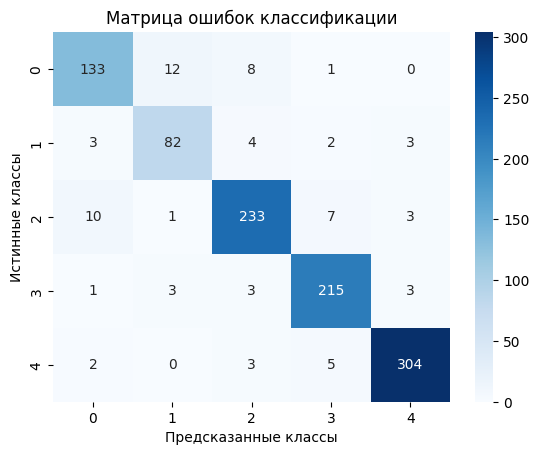

Улучшение метрики F1 macro: 0.908->0.914 (0.65%)


In [75]:
final_pipeline = pipe(svm(
        kernel='rbf',
        tol=svm_grid_result.best_params_['estimator__estimator__tol']
    ),
    mcc='ovr',
    preproc=preprocessor_enhanced
)

final_pipeline.fit(X_train_val, y_train_val)
y_pred_final = final_pipeline.predict(X_test)

f1_macro_final = f1_score(y_test, y_pred_final, average="macro")
print('-'*50)
print(f'Метрика f1_marco финальной модели: {f1_macro_final:.2f}')
print('-'*50)
print(classification_report(y_test, y_pred_final, digits=2))
ax = sns.heatmap(
    confusion_matrix(y_test, y_pred_final),
    annot=True,
    cmap='Blues',
    fmt='d',
)
ax.set(
    xlabel='Предсказанные классы',
    ylabel='Истинные классы',
    title='Матрица ошибок классификации',
)
plt.show()
compare_metrics(enhanced_f1_macro, f1_macro_final, 'F1 macro', pct_digits=2)

Финальный скор модели по метрике $f1_{macro} = 0.91$

Есть незначительная просадка качества модели при предсказании возрастного класса 1 ($f1 = 0.85$), но данные показатели удовлетворяют приемочным условиям.

Сохраним модель для использования в продакшене:

In [76]:
VERSION=1.0
date = datetime.now().strftime('%Y_%m_%d')
model_name = f"user_age_classification_model_v{VERSION}_{date}.joblib"

ALL_FEATURES = NUM_FEATURES_ENHANCED + OHE_FEATURES + TARGET_ENCODED_FEATURES

metadata = {
    'model_version': f'{VERSION}',
    'training_date': f'{date}',
    'f1_macro': f1_macro_final,
    'features': ALL_FEATURES,
}

joblib.dump(
    {
        'model': final_pipeline,
        'metadata': metadata,
        'user_profile_maker': user_profile_maker,
    },
    model_name,
)

['user_age_classification_model_v1.0_2026_03_28.joblib']

Проверим работоспособность десериализованной модели.

Обработаем исходные таблицы восстановленным user_profile_maker

In [77]:
loaded_model = joblib.load(f'{model_name}')
loaded_user_profile_maker = loaded_model['user_profile_maker']
restored_df = loaded_user_profile_maker.make_df_user_profile(
    df_users,
    df_visits,
    df_ads_activity,
    df_cloud_usage,
    df_primary_device,
    df_surf_depth,
)
restored_df = loaded_user_profile_maker.merge_additional_features(restored_df, df_visits)

In [78]:
user_id_1_age_cat = '9e1a-e249e20de7389f9a9e22-c05fdc27'

some_user_df = restored_df.query(f'user_id == "{user_id_1_age_cat}"')
real_class = some_user_df.iloc[0]['age_category']
predicted_class = loaded_model['model'].predict(some_user_df)
print(f'Предсказанный класс возраста: {predicted_class}')
print(f'Действительный класс возраста: {real_class}')
assert real_class == predicted_class, f'Предсказанный возраст не совпадает с действительным'


Предсказанный класс возраста: [1]
Действительный класс возраста: 1


<a id="final-report"></a>

## Выводы о результатах работы

Поставленная перед исследованием задача - мультиклассовая классификация пользователей рекламной сети РСЙ компании Yeti по возрастным группам, выполнена успешно. Преодолен порог целевой метрики - F1-macro >= 0.75.

Возрастные группы (классы возрастных групп):
- 0: младше 18;
- 1: 18-25 лет;
- 2: 26-40 лет;
- 3: 41-55 лет;
- 4: 56+ лет.

Данные собраны из шести источников: таблица пользователей (5913 строк), журнал посещений (~1 млн строк), активность по рекламе, глубина сёрфинга, основное устройство и использование облака. Все источники объединены по идентификатору пользователя.

При объединении были выявлены пропуски в объеме 10% от исходного датасета. Так как данных для обучения было достаточно, они были удалены.

На этапе исследовательского анализа данных были выявлена связь времени выхода в интернет и предпочтительные категории сайтов с целевой переменной.

Предобработка включала заполнение пропусков, кодирование категориальных признаков - OneHotEncoder для признаков с небольшим числом категорий и TargetEncoder для высококардинальных, масштабирование числовых признаков StandardScaler. Всё это упаковано в Pipeline с ColumnTransformer.

Базовая модель - SVM с ядром RBF и стратегией One-vs-Rest - показала F1-macro = 0.48 на исходных признаках. Это ожидаемо: поведенческие данные из журнала посещений были агрегированы на первом этапе только в несколько признаков:
- предпочтительное время выхода в интернет ползователем (preferable_daytime)
- предпочтительная категория сайтов (preferable_website_cat)
- среднее число сессий в день (mean_session_count_per_1d)

Первые два признака показали занчительную полезность и находились в топе по важности при оценке через модель логистичесекой регрессии.

При выборе бейзлайн модели были перебраны несколько архитектур: логистическая регрессия, SVM с различными ядрами, комбинации этих моделей с разными стратегиями обучения внутренних бинарных классификаторов - One-vs-Rest и One-vs-One. 

Ключевым шагом улучшения качества модели стала инженерия признаков на основе журнала посещений. Были добавлены: доли посещений по категориям сайтов (20 признаков) и доли посещений по времени суток (4 признака). После добавления этих признаков F1-macro вырос до 0.908 - прирост составил 88%.

Подбор гиперпараметров через GridSearchCV дал незначиельные улучшения: оптимальное значение tol=0.2 подняло метрику F1-macro до 0.910 на валидационной выборке.

Финальная модель - OneVsRestClassifier(SVC(kernel='rbf', tol=0.2)) - показала на тестовой выборке:

- F1-macro = 0.91
- Precision-macro = 0.91
- Recall-macro = 0.92

По классам наиболее уверенно модель распознаёт старшие возрастные группы: класс 56+ (f1=0.97), 41-55 (f1=0.95), 26-40 (f1=0.92). Сложнее всего даётся класс 18-25 (f1=0.85) - вероятно, из-за пересечения поведенческих паттернов с соседними группами и меньшего числа примеров в обучающей выборке.

Анализ коэффициентов логистической регрессии (как интерпретируемого прокси) показал, что наибольший вклад вносят: предпочтительное время суток - дневное (preferable_daytime_день, коэф. -1.07), предпочтительная категория сайтов (preferable_website_cat_0, коэф. 0.43), частота взаимодействия с рекламой (ads_activity_часто, коэф. -0.39), использование смартфона как основного устройства (primary_device_смартфон, коэф. 0.39) и использование облака (cloud_usage, коэф. -0.38).

Целевая метрика достигнута с запасом: F1-macro = 0.91 при пороге 0.75. Основной вклад в качество модели внесла инженерия признаков из журнала посещений - именно агрегированные поведенческие паттерны (время суток, категории сайтов, интенсивность сессий) оказались наиболее информативными для разделения возрастных групп. Модель сохранена в файл user_age_classification_model_v1.0_2026_03_28.joblib.